# SAE Feature: Mechanism Detector or Language Detector?

**Goal:** Determine whether a given SAE feature encodes a genuine vulnerability mechanism or merely correlates with a programming language.

**Change only the config cell below to analyse a different feature.**

## Experiments

1. **Within-primary-CWE-family t-test** — holds CWE type constant, varies only label (secure vs. vuln). A language detector shows no difference here if the CWE family is multi-language.
2. **Within-dominant-language t-test** — holds language constant, varies only label. A language detector shows no difference here.
3. **Fisher score: language vs. vulnerability** — ranks the feature against all 16k features under both labelling schemes. Also checks Fisher against the dominant language(s) of the target CWE family.
4. **Per-language AUC** — does the feature discriminate within each language?
5. **CWE × Language interaction heatmap** — AUC broken down by CWE and language family.
6. **Within-primary-CWE-family per-language AUC** *(key test)* — if the feature is mechanistic, it should discriminate *within each language* that exhibits the target CWE type.

In [39]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
# ── CONFIG ── change only this cell ─────────────────────────────────────────
FEATURE = 438#1267                    # SAE feature index to analyse
LAYER   = 11                     # layer the activations were collected from
RUN_ID  = "run_20260218_134529_vulnerable_code_qwen_coder_standard_16384_10M"
#RUN_ID  = "layer0"

# CWE family this feature is hypothesised to encode.
# Used to drive Exp 1, 2b and 6.  One of: "injection" | "memory" | "other"
PRIMARY_CWE_FAMILY = "memory"#"injection"
# ────────────────────────────────────────────────────────────────────────────

# CWE groupings
MEMORY_CWES    = {"CWE-119", "CWE-125", "CWE-787", "CWE-416", "CWE-401", "CWE-190", "CWE-476"}
INJECTION_CWES = {"CWE-89",  "CWE-79",  "CWE-94",  "CWE-78"}

# Language families
C_FAMILY = {"c", "cc", "cpp", "h", "cxx"}
# Dominant languages for each CWE family (used in Exp 2 and 6)
DOMINANT_LANGS = {
    "injection": {"php", "js", "py", "rb", "java"},
    "memory":    {"c", "cc", "cpp", "h", "cxx"},
    "other":     set(),
}

In [41]:
import glob
import orjson
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
from scipy.stats import ttest_ind, mannwhitneyu
from sklearn.metrics import roc_auc_score

FEAT_COL  = "feat_val"   # generic column name — works for any FEATURE index
DOM_LANGS = DOMINANT_LANGS.get(PRIMARY_CWE_FAMILY, set())

## Load data

In [42]:
files = sorted(glob.glob(f"../../artifacts/activations/{RUN_ID}/activations_layer_{LAYER}_*.jsonl"))
print(f"Found {len(files)} file(s): {files}")

records = []
with open(files[0]) as f:
    for line in tqdm(f, desc="Loading"):
        d    = orjson.loads(line)
        ext  = d["file_extension"].lower().lstrip(".")
        cwe  = d["cwe"]
        fam  = ("memory"    if cwe in MEMORY_CWES
                else "injection" if cwe in INJECTION_CWES
                else "other")
        is_c   = ext in C_FAMILY
        is_dom = ext in DOM_LANGS

        base = dict(vuln_id=d["vuln_id"], cwe=cwe, lang=ext,
                    is_c=is_c, is_dom_lang=is_dom, cwe_family=fam)

        records.append({**base, "label": 0,
                        FEAT_COL: d["secure"][FEATURE],
                        "activations": d["secure"]})
        records.append({**base, "label": 1,
                        FEAT_COL: d["vulnerable"][FEATURE],
                        "activations": d["vulnerable"]})

df         = pd.DataFrame(records)
act_matrix = np.array(df["activations"].tolist(), dtype=np.float32)
df         = df.drop(columns=["activations"])
df["lang_family"] = df["is_c"].map({True: "C-family", False: "non-C"})

print(f"\nTotal rows : {len(df)}")
print(f"C-family   : {df['is_c'].sum()}")
print(f"non-C      : {(~df['is_c']).sum()}")
print(f"Primary CWE family ('{PRIMARY_CWE_FAMILY}') rows: {(df['cwe_family'] == PRIMARY_CWE_FAMILY).sum()}")
print()
print(df.groupby(["cwe_family", "lang"])["label"].count()
        .unstack(fill_value=0).head(25))

Found 1 file(s): ['../../artifacts/activations/run_20260218_134529_vulnerable_code_qwen_coder_standard_16384_10M/activations_layer_11_sae_blocks.11.hook_resid_post_component_hook_resid_post.hook_sae_acts_post.jsonl']


Loading: 0it [00:00, ?it/s]


Total rows : 4986
C-family   : 3236
non-C      : 1750
Primary CWE family ('memory') rows: 2104

lang           c   cc  cpp  cs  go  html  java   js  php  py  rb  rs  ts  xml
cwe_family                                                                   
injection     14    2    2   8  10    20    20  164  746  46  28   0  20    6
memory      1748  230   86   0   6     0     6    4    8   0   0  16   0    0
other        974  120   60   8  36     0    62  134  282  64  30  16   8    2


---
## Experiment 1: Within-primary-CWE-family t-test

Restricts to the CWE family the feature is hypothesised to encode (`PRIMARY_CWE_FAMILY`).
Within this subset the analysis spans all languages, so it is no longer confounded by a single-language correlation.

**Null (language-detector):** no difference between secure and vulnerable — the feature only tracks which language the code is in, not whether it is buggy.

=== Exp 1: Within-memory-CWE comparison (feature 1267) ===
  Secure  — n=1052  mean=0.1114  std=0.1271
  Vuln    — n=1052  mean=0.1074  std=0.1247
  Welch t-test: t=-0.742  p=0.4583
  Mann-Whitney: p=0.5273
  Cohen's d = -0.032
  AUC = 0.492

VERDICT: No significant difference within memory CWEs → consistent with language-detector hypothesis.


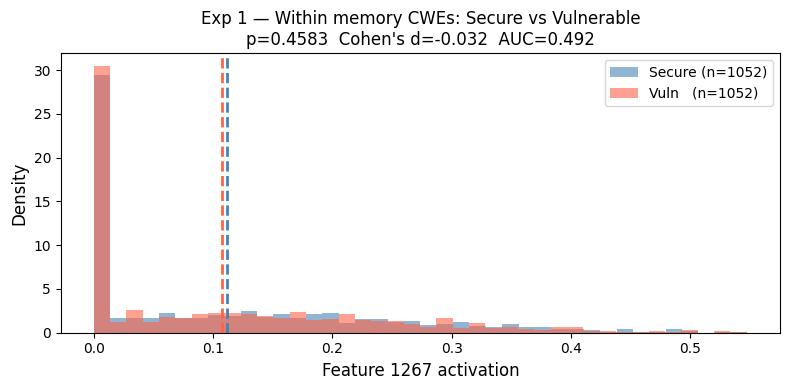

In [43]:
prim_df  = df[df["cwe_family"] == PRIMARY_CWE_FAMILY]
p_secure = prim_df[prim_df["label"] == 0][FEAT_COL].values
p_vuln   = prim_df[prim_df["label"] == 1][FEAT_COL].values

t1, p1   = ttest_ind(p_vuln, p_secure, equal_var=False)
_, p1_mw = mannwhitneyu(p_vuln, p_secure, alternative="two-sided")
std1     = np.sqrt((p_secure.std()**2 + p_vuln.std()**2) / 2 + 1e-12)
d1       = (p_vuln.mean() - p_secure.mean()) / std1
auc1     = roc_auc_score(
    np.r_[np.zeros(len(p_secure)), np.ones(len(p_vuln))],
    np.r_[p_secure, p_vuln]
)

print(f"=== Exp 1: Within-{PRIMARY_CWE_FAMILY}-CWE comparison (feature {FEATURE}) ===")
print(f"  Secure  — n={len(p_secure):4d}  mean={p_secure.mean():.4f}  std={p_secure.std():.4f}")
print(f"  Vuln    — n={len(p_vuln):4d}  mean={p_vuln.mean():.4f}  std={p_vuln.std():.4f}")
print(f"  Welch t-test: t={t1:.3f}  p={p1:.4f}")
print(f"  Mann-Whitney: p={p1_mw:.4f}")
print(f"  Cohen's d = {d1:.3f}")
print(f"  AUC = {auc1:.3f}")
print()
if p1 < 0.05 and abs(d1) > 0.2:
    print(f"VERDICT: Feature {FEATURE} discriminates WITHIN {PRIMARY_CWE_FAMILY} CWEs "
          "→ NOT a pure language-detector for this CWE family.")
elif p1 < 0.05:
    print(f"VERDICT: Significant but small effect (|d|<0.2) — weak mechanistic signal.")
else:
    print(f"VERDICT: No significant difference within {PRIMARY_CWE_FAMILY} CWEs "
          "→ consistent with language-detector hypothesis.")

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(p_secure, bins=40, alpha=0.6, color="steelblue", density=True,
        label=f"Secure (n={len(p_secure)})")
ax.hist(p_vuln,   bins=40, alpha=0.6, color="tomato",    density=True,
        label=f"Vuln   (n={len(p_vuln)})")
ax.axvline(p_secure.mean(), color="steelblue", linestyle="--", lw=2)
ax.axvline(p_vuln.mean(),   color="tomato",    linestyle="--", lw=2)
ax.set_xlabel(f"Feature {FEATURE} activation", fontsize=12)
ax.set_ylabel("Density", fontsize=12)
ax.set_title(f"Exp 1 — Within {PRIMARY_CWE_FAMILY} CWEs: Secure vs Vulnerable\n"
             f"p={p1:.4f}  Cohen's d={d1:.3f}  AUC={auc1:.3f}", fontsize=12)
ax.legend()
plt.tight_layout()
plt.savefig(f"exp1_within_{PRIMARY_CWE_FAMILY}_feature{FEATURE}.png", dpi=150)
plt.show()

---
## Experiment 2: Within-dominant-language t-test

Holds language constant (the dominant language(s) for the primary CWE family) and checks whether the feature still separates secure from vulnerable. This is the direct language-confound control.

Dominant-language subset: ['c', 'cc', 'cpp']  (n_pairs=1618)
  Secure  — mean=0.1167  std=0.1301
  Vuln    — mean=0.1127  std=0.1284
  Welch t: t=-0.878  p=0.3800
  Cohen's d = -0.031  AUC = 0.491

VERDICT: No significant difference within dominant languages → language-detector hypothesis holds.


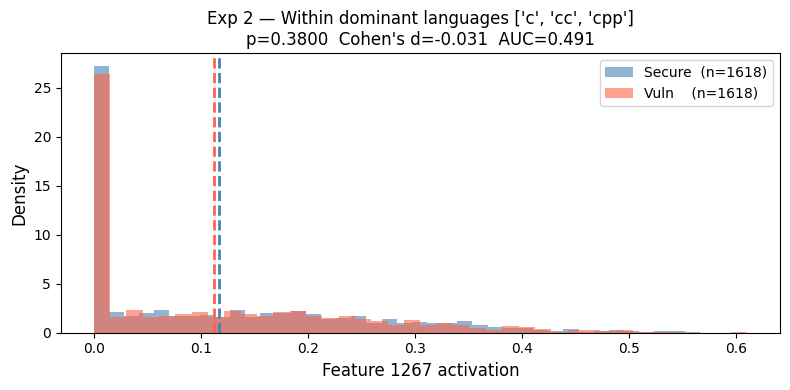

In [44]:
dom_df   = df[df["is_dom_lang"]]
d2_sec   = dom_df[dom_df["label"] == 0][FEAT_COL].values
d2_vuln  = dom_df[dom_df["label"] == 1][FEAT_COL].values

dom_langs_present = sorted(dom_df["lang"].unique().tolist())
print(f"Dominant-language subset: {dom_langs_present}  (n_pairs={len(d2_sec)})")

if len(d2_sec) > 1 and len(d2_vuln) > 1:
    t2, p2   = ttest_ind(d2_vuln, d2_sec, equal_var=False)
    _, p2_mw = mannwhitneyu(d2_vuln, d2_sec, alternative="two-sided")
    std2     = np.sqrt((d2_sec.std()**2 + d2_vuln.std()**2) / 2 + 1e-12)
    d2       = (d2_vuln.mean() - d2_sec.mean()) / std2
    auc2     = roc_auc_score(
        np.r_[np.zeros(len(d2_sec)), np.ones(len(d2_vuln))],
        np.r_[d2_sec, d2_vuln]
    )
    print(f"  Secure  — mean={d2_sec.mean():.4f}  std={d2_sec.std():.4f}")
    print(f"  Vuln    — mean={d2_vuln.mean():.4f}  std={d2_vuln.std():.4f}")
    print(f"  Welch t: t={t2:.3f}  p={p2:.4f}")
    print(f"  Cohen's d = {d2:.3f}  AUC = {auc2:.3f}")
    print()
    if p2 < 0.05 and abs(d2) > 0.2:
        print("VERDICT: Significant within dominant-language subset → feature is NOT purely a language detector.")
    else:
        print("VERDICT: No significant difference within dominant languages → language-detector hypothesis holds.")
else:
    print("Not enough data in dominant-language subset.")
    p2, d2, auc2 = 1.0, 0.0, 0.5

fig, ax = plt.subplots(figsize=(8, 4))
if len(d2_sec) > 0:
    ax.hist(d2_sec,  bins=40, alpha=0.6, color="steelblue", density=True, label=f"Secure  (n={len(d2_sec)})")
    ax.hist(d2_vuln, bins=40, alpha=0.6, color="tomato",    density=True, label=f"Vuln    (n={len(d2_vuln)})")
    ax.axvline(d2_sec.mean(),  color="steelblue", linestyle="--", lw=2)
    ax.axvline(d2_vuln.mean(), color="tomato",    linestyle="--", lw=2)
ax.set_xlabel(f"Feature {FEATURE} activation", fontsize=12)
ax.set_ylabel("Density", fontsize=12)
ax.set_title(f"Exp 2 — Within dominant languages {dom_langs_present}\n"
             f"p={p2:.4f}  Cohen's d={d2:.3f}  AUC={auc2:.3f}", fontsize=12)
ax.legend()
plt.tight_layout()
plt.savefig(f"exp2_within_dom_lang_feature{FEATURE}.png", dpi=150)
plt.show()

---
## Experiment 3: Fisher score — language label vs. vulnerability label

Ranks the feature against ALL 16 384 features under four labelling schemes:
- `F_lang_c`: C vs. non-C
- `F_lang_dom`: dominant-language vs. rest (e.g. PHP/JS vs. rest for injection)
- `F_vuln`: secure vs. vulnerable (global)
- `F_vuln_prim`: secure vs. vulnerable *within primary CWE family only*

In [45]:
def compute_all_fisher(matrix: np.ndarray, labels: np.ndarray) -> np.ndarray:
    g0 = matrix[labels == 0]
    g1 = matrix[labels == 1]
    diff_sq = (g0.mean(0) - g1.mean(0)) ** 2
    denom   = g0.var(0) + g1.var(0) + 1e-12
    return diff_sq / denom

n_feat = act_matrix.shape[1]

print("Computing Fisher scores (4 label schemes) …")
fisher_lang_c   = compute_all_fisher(act_matrix, df["is_c"].astype(int).values)
fisher_lang_dom = compute_all_fisher(act_matrix, df["is_dom_lang"].astype(int).values)
fisher_vuln     = compute_all_fisher(act_matrix, df["label"].values)

prim_mask = (df["cwe_family"] == PRIMARY_CWE_FAMILY).values
fisher_vuln_prim = (
    compute_all_fisher(act_matrix[prim_mask], df.loc[prim_mask, "label"].values)
    if prim_mask.sum() > 0 else np.zeros(n_feat)
)

def rank_of(scores, idx):
    return int((scores >= scores[idx]).sum())

print(f"\nFeature {FEATURE}:")
print(f"  F_lang_c        = {fisher_lang_c[FEATURE]:.4f}   rank {rank_of(fisher_lang_c,   FEATURE):5d} / {n_feat}")
print(f"  F_lang_dom      = {fisher_lang_dom[FEATURE]:.4f}   rank {rank_of(fisher_lang_dom, FEATURE):5d} / {n_feat}")
print(f"  F_vuln (global) = {fisher_vuln[FEATURE]:.4f}   rank {rank_of(fisher_vuln,     FEATURE):5d} / {n_feat}")
print(f"  F_vuln_{PRIMARY_CWE_FAMILY:9s} = {fisher_vuln_prim[FEATURE]:.4f}   rank {rank_of(fisher_vuln_prim, FEATURE):5d} / {n_feat}")

best_lang = max(fisher_lang_c[FEATURE], fisher_lang_dom[FEATURE])
best_vuln = max(fisher_vuln[FEATURE],   fisher_vuln_prim[FEATURE])
ratio = best_lang / (best_vuln + 1e-12)
print(f"\n  Ratio best_F_lang / best_F_vuln = {ratio:.2f}")
if ratio > 3:
    print("VERDICT: Language signal dominates → likely a language detector.")
elif ratio < 0.33:
    print("VERDICT: Vulnerability signal dominates → supports mechanism detector.")
else:
    print("VERDICT: Mixed — feature has both language and vulnerability signal.")

top_lang  = np.argsort(fisher_lang_c)[::-1][:10]
top_vuln  = np.argsort(fisher_vuln)[::-1][:10]
top_vprim = np.argsort(fisher_vuln_prim)[::-1][:10]
print(f"\nTop-10 by F_lang_c:         {top_lang.tolist()}")
print(f"Top-10 by F_vuln:            {top_vuln.tolist()}")
print(f"Top-10 by F_vuln_{PRIMARY_CWE_FAMILY}: {top_vprim.tolist()}")
print(f"Feature {FEATURE} in top-10 F_lang_c?          {FEATURE in top_lang}")
print(f"Feature {FEATURE} in top-10 F_vuln?             {FEATURE in top_vuln}")
print(f"Feature {FEATURE} in top-10 F_vuln_{PRIMARY_CWE_FAMILY}?   {FEATURE in top_vprim}")

Computing Fisher scores (4 label schemes) …

Feature 1267:
  F_lang_c        = 0.1701   rank   382 / 16384
  F_lang_dom      = 0.1701   rank   382 / 16384
  F_vuln (global) = 0.0003   rank  6184 / 16384
  F_vuln_memory    = 0.0005   rank  6930 / 16384

  Ratio best_F_lang / best_F_vuln = 324.96
VERDICT: Language signal dominates → likely a language detector.

Top-10 by F_lang_c:         [9554, 14691, 11464, 3453, 15026, 4802, 4650, 1191, 5118, 1198]
Top-10 by F_vuln:            [80, 12209, 12144, 11280, 13011, 15596, 14439, 7257, 6401, 903]
Top-10 by F_vuln_memory: [80, 12209, 12144, 13011, 15596, 13311, 10925, 3362, 11280, 8200]
Feature 1267 in top-10 F_lang_c?          False
Feature 1267 in top-10 F_vuln?             False
Feature 1267 in top-10 F_vuln_memory?   False


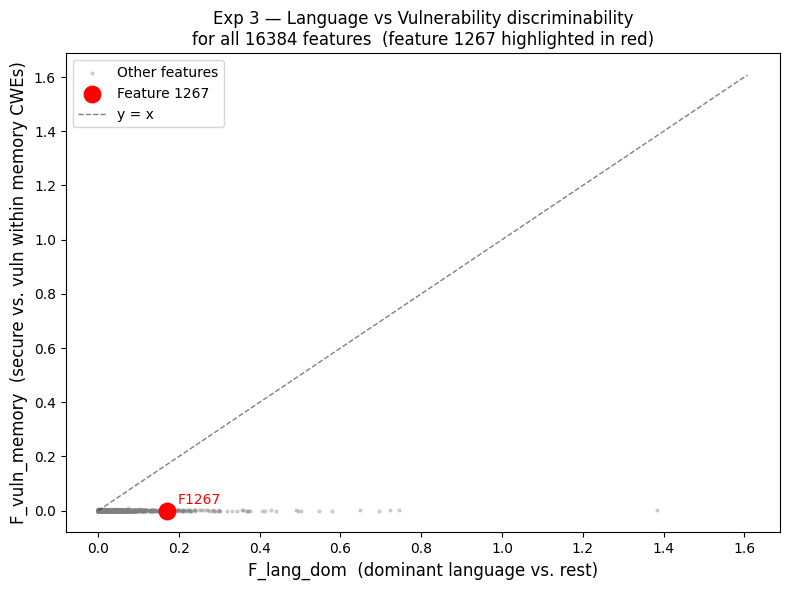

In [46]:
# Scatter: F_lang_dom vs F_vuln_prim for every feature
fig, ax = plt.subplots(figsize=(8, 6))
rng = np.random.default_rng(42)
idx = rng.choice(n_feat, size=min(3000, n_feat), replace=False)

ax.scatter(fisher_lang_dom[idx], fisher_vuln_prim[idx],
           s=4, alpha=0.3, color="gray", label="Other features")
ax.scatter(fisher_lang_dom[FEATURE], fisher_vuln_prim[FEATURE],
           s=140, color="red", zorder=5, label=f"Feature {FEATURE}")
ax.annotate(f"F{FEATURE}",
            (fisher_lang_dom[FEATURE], fisher_vuln_prim[FEATURE]),
            xytext=(8, 5), textcoords="offset points", fontsize=10, color="red")

lim = max(fisher_lang_dom.max(), fisher_vuln_prim.max()) * 1.05
ax.plot([0, lim], [0, lim], "k--", lw=1, alpha=0.5, label="y = x")
ax.set_xlabel("F_lang_dom  (dominant language vs. rest)", fontsize=12)
ax.set_ylabel(f"F_vuln_{PRIMARY_CWE_FAMILY}  (secure vs. vuln within {PRIMARY_CWE_FAMILY} CWEs)", fontsize=12)
ax.set_title(f"Exp 3 — Language vs Vulnerability discriminability\n"
             f"for all {n_feat} features  (feature {FEATURE} highlighted in red)", fontsize=12)
ax.legend()
plt.tight_layout()
plt.savefig(f"exp3_fisher_scatter_feature{FEATURE}.png", dpi=150)
plt.show()

---
## Experiment 4: Per-language AUC

AUC(secure vs. vulnerable) for feature `FEATURE` within each language separately.

- **Language detector:** AUC ≈ 0.5 in every language (feature value doesn't shift with vulnerability within a language).
- **Mechanism detector:** AUC > 0.5 in languages that exhibit the target vulnerability type.

> ⚠️  AUC ≈ 0.5 in **all** languages means the feature has *no discriminability anywhere* — this is a language detector with zero vulnerability signal, not a mechanism detector.

In [47]:
lang_results = []
for lang, grp in df.groupby("lang"):
    if grp["label"].nunique() < 2 or len(grp) // 2 < 10:
        continue
    sec  = grp[grp["label"] == 0][FEAT_COL].values
    vuln = grp[grp["label"] == 1][FEAT_COL].values
    try:
        auc = roc_auc_score(grp["label"], grp[FEAT_COL])
    except Exception:
        auc = float("nan")
    _, p = (ttest_ind(vuln, sec, equal_var=False)
            if len(sec) > 1 and len(vuln) > 1 else (0, 1.0))
    pooled = np.sqrt((sec.std()**2 + vuln.std()**2) / 2 + 1e-12)
    d = (vuln.mean() - sec.mean()) / pooled
    lang_results.append(dict(lang=lang, is_c=lang in C_FAMILY,
                             is_dom=lang in DOM_LANGS,
                             n_pairs=len(sec), auc=auc, cohens_d=d,
                             p_value=p,
                             vuln_mean=vuln.mean(), secure_mean=sec.mean()))

lang_df = pd.DataFrame(lang_results).sort_values("auc", ascending=False)
print(lang_df.to_string(index=False, float_format="{:.3f}".format))

c_auc     = lang_df[lang_df["is_c"]]["auc"].mean()
dom_auc   = lang_df[lang_df["is_dom"]]["auc"].mean() if lang_df["is_dom"].any() else float("nan")
non_c_auc = lang_df[~lang_df["is_c"]]["auc"].mean()
print(f"\nMean AUC — C-family: {c_auc:.3f}  |  dominant langs: {dom_auc:.3f}  |  non-C: {non_c_auc:.3f}")

# Verdict — check actual AUC levels, not just relative similarity
all_near_chance  = lang_df["auc"].apply(lambda x: abs(x - 0.5) < 0.03).all()
dom_above_chance = (lang_df[lang_df["is_dom"]]["auc"] > 0.55).any() if lang_df["is_dom"].any() else False

print()
if all_near_chance:
    print("VERDICT: AUC ≈ 0.5 in every language → feature has NO vulnerability discriminability anywhere.")
elif dom_above_chance and (c_auc < 0.53 or not lang_df["is_c"].any()):
    print("VERDICT: AUC > 0.55 in dominant language(s) but not in C-family → cross-language mechanism signal.")
elif dom_auc > 0.55:
    print("VERDICT: AUC elevated in dominant language(s) → possible mechanism detector.")
else:
    print("VERDICT: Mixed — inspect the per-language table above.")

lang  is_c  is_dom  n_pairs   auc  cohens_d  p_value  vuln_mean  secure_mean
  rs False   False       16 0.547    -0.035    0.924      0.037        0.040
html False   False       10 0.520     0.023    0.961      0.120        0.116
  go False   False       26 0.513    -0.003    0.991      0.079        0.080
 php False   False      518 0.501    -0.005    0.934      0.041        0.041
  rb False   False       29 0.499     0.013    0.962      0.030        0.029
java False   False       44 0.497    -0.043    0.841      0.075        0.079
   c  True    True     1368 0.493    -0.028    0.468      0.114        0.117
 cpp  True    True       74 0.493    -0.021    0.897      0.095        0.098
  js False   False      151 0.490    -0.025    0.829      0.050        0.053
  py False   False       55 0.486    -0.032    0.868      0.075        0.079
  ts False   False       14 0.474    -0.043    0.913      0.067        0.072
  cc  True    True      176 0.473    -0.055    0.608      0.114        0.122

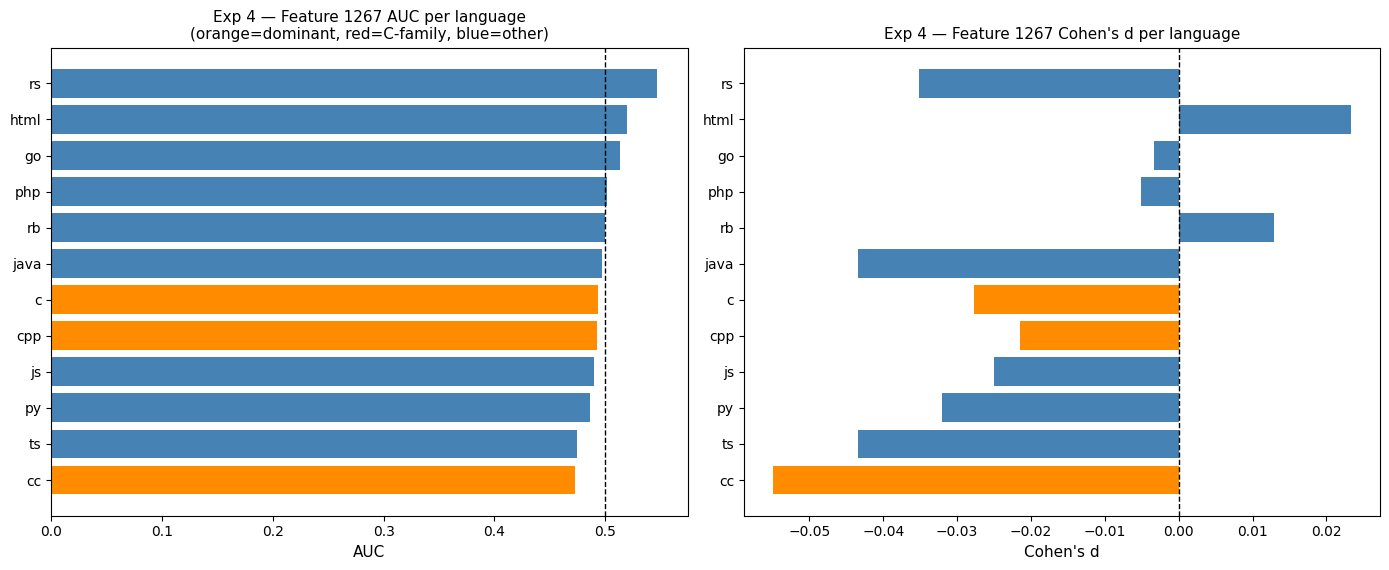

In [48]:
def lang_color(row):
    if row["is_dom"]: return "darkorange"
    if row["is_c"]:   return "tomato"
    return "steelblue"

colors = [lang_color(r) for _, r in lang_df.iterrows()]
fig, axes = plt.subplots(1, 2, figsize=(14, max(4, len(lang_df) * 0.4 + 1)))

axes[0].barh(lang_df["lang"], lang_df["auc"], color=colors)
axes[0].axvline(0.5, color="black", linestyle="--", lw=1)
axes[0].set_xlabel("AUC", fontsize=11)
axes[0].set_title(f"Exp 4 — Feature {FEATURE} AUC per language\n"
                  "(orange=dominant, red=C-family, blue=other)", fontsize=11)
axes[0].invert_yaxis()

axes[1].barh(lang_df["lang"], lang_df["cohens_d"], color=colors)
axes[1].axvline(0, color="black", linestyle="--", lw=1)
axes[1].set_xlabel("Cohen's d", fontsize=11)
axes[1].set_title(f"Exp 4 — Feature {FEATURE} Cohen's d per language", fontsize=11)
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig(f"exp4_per_language_auc_feature{FEATURE}.png", dpi=150)
plt.show()

---
## Experiment 5: CWE × Language interaction heatmap

    cwe lang_family   auc   n cwe_family
 CWE-79       non-C 0.503 385  injection
 CWE-78       non-C 0.488  36  injection
 CWE-89       non-C 0.485  82  injection
 CWE-94       non-C 0.483  31  injection
CWE-416    C-family 0.508 110     memory
CWE-401    C-family 0.503  70     memory
CWE-476    C-family 0.499 178     memory
CWE-119    C-family 0.493 219     memory
CWE-125    C-family 0.488 217     memory
CWE-190    C-family 0.482  75     memory
CWE-787    C-family 0.480 163     memory
CWE-362       non-C 0.514  12      other
CWE-352       non-C 0.510  30      other
CWE-415    C-family 0.510  35      other
CWE-264    C-family 0.510  38      other
CWE-434       non-C 0.508  29      other
CWE-189    C-family 0.502  36      other
 CWE-20       non-C 0.501  52      other
CWE-200       non-C 0.500  43      other
CWE-400       non-C 0.496  45      other
CWE-200    C-family 0.494 100      other
CWE-120    C-family 0.493  42      other
CWE-264       non-C 0.491  13      other
CWE-362    C-fam

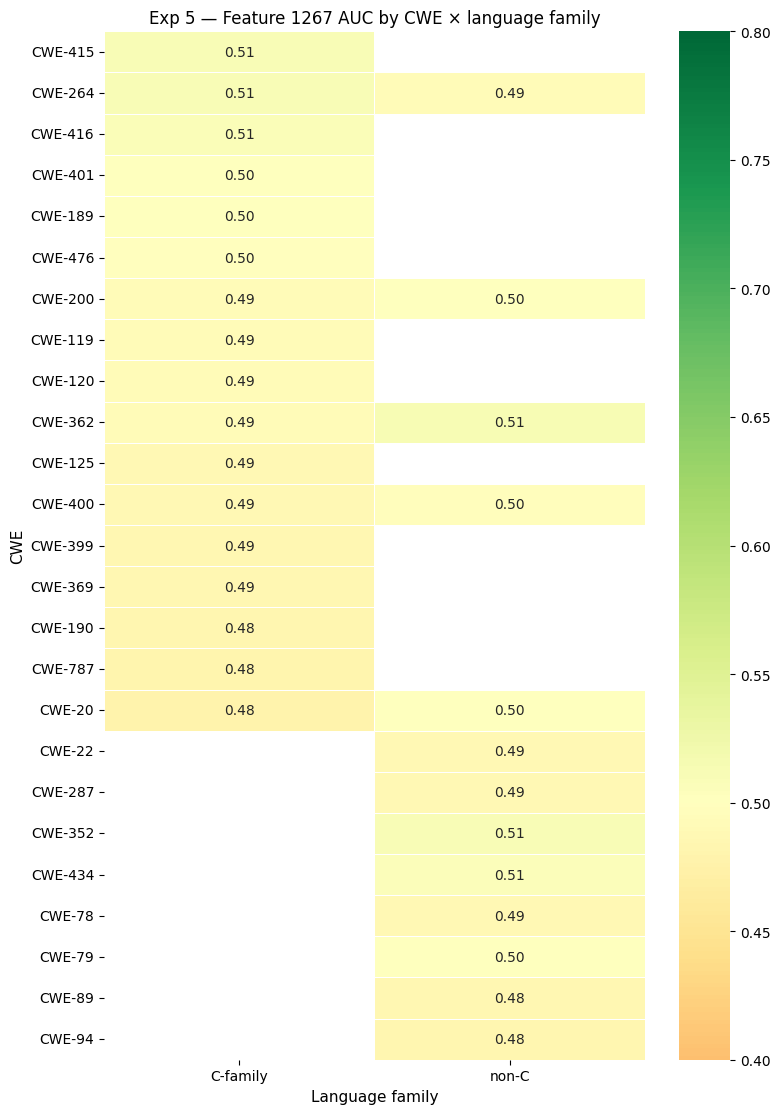

In [49]:
rows = []
for cwe, grp in df.groupby("cwe"):
    for lf, sub in grp.groupby("lang_family"):
        if sub["label"].nunique() < 2 or len(sub) < 20:
            continue
        try:
            auc = roc_auc_score(sub["label"], sub[FEAT_COL])
        except Exception:
            continue
        rows.append(dict(cwe=cwe, lang_family=lf, auc=auc,
                         n=len(sub) // 2,
                         cwe_family=sub["cwe_family"].iloc[0]))

cwe_lang_df = pd.DataFrame(rows)
print(cwe_lang_df.sort_values(["cwe_family", "auc"], ascending=[True, False])
      .to_string(index=False, float_format="{:.3f}".format))

if not cwe_lang_df.empty:
    pivot_auc = cwe_lang_df.pivot_table(
        index="cwe", columns="lang_family", values="auc", aggfunc="mean"
    )
    sort_col = "C-family" if "C-family" in pivot_auc.columns else pivot_auc.columns[0]
    pivot_auc = pivot_auc.sort_values(sort_col, ascending=False, na_position="last")

    fig, ax = plt.subplots(figsize=(8, max(4, len(pivot_auc) * 0.45)))
    sns.heatmap(pivot_auc, annot=True, fmt=".2f", cmap="RdYlGn",
                vmin=0.4, vmax=0.8, center=0.5, linewidths=0.5, ax=ax)
    ax.set_title(f"Exp 5 — Feature {FEATURE} AUC by CWE × language family", fontsize=12)
    ax.set_xlabel("Language family", fontsize=11)
    ax.set_ylabel("CWE", fontsize=11)
    plt.tight_layout()
    plt.savefig(f"exp5_cwe_language_heatmap_feature{FEATURE}.png", dpi=150)
    plt.show()

---
## Experiment 6: Within-primary-CWE-family, per-language AUC  *(key test)*

This is the decisive experiment for feature 438 (injection hypothesis).

Restricts the data to **only injection CWEs**, then computes AUC **within each language** separately.

| Scenario | What we expect |
|---|---|
| Single-language detector (e.g. PHP detector) | AUC > 0.5 only in one dominant language, ≈ 0.5 in others |
| Mechanism detector | AUC > 0.5 in **multiple** languages that exhibit the same injection pattern |

In [50]:
prim_only = df[df["cwe_family"] == PRIMARY_CWE_FAMILY]

exp6_rows = []
for lang, grp in prim_only.groupby("lang"):
    if grp["label"].nunique() < 2 or len(grp) // 2 < 5:
        continue
    sec  = grp[grp["label"] == 0][FEAT_COL].values
    vuln = grp[grp["label"] == 1][FEAT_COL].values
    try:
        auc = roc_auc_score(grp["label"], grp[FEAT_COL])
    except Exception:
        auc = float("nan")
    _, p = (ttest_ind(vuln, sec, equal_var=False)
            if len(sec) > 1 and len(vuln) > 1 else (0, 1.0))
    pooled = np.sqrt((sec.std()**2 + vuln.std()**2) / 2 + 1e-12)
    d = (vuln.mean() - sec.mean()) / pooled
    exp6_rows.append(dict(lang=lang, n_pairs=len(sec), auc=auc, cohens_d=d,
                          p_value=p, is_dom=lang in DOM_LANGS,
                          secure_mean=sec.mean(), vuln_mean=vuln.mean()))

exp6_df = pd.DataFrame(exp6_rows).sort_values("auc", ascending=False)
print(f"=== Exp 6: Within {PRIMARY_CWE_FAMILY} CWEs — per-language AUC (feature {FEATURE}) ===")
print(exp6_df.to_string(index=False, float_format="{:.3f}".format))

n_above_55 = int((exp6_df["auc"] > 0.55).sum())
n_above_60 = int((exp6_df["auc"] > 0.60).sum())
print(f"\nLanguages with AUC > 0.55: {n_above_55} / {len(exp6_df)}")
print(f"Languages with AUC > 0.60: {n_above_60} / {len(exp6_df)}")
print()

if n_above_55 >= 2:
    langs_above = exp6_df[exp6_df["auc"] > 0.55]["lang"].tolist()
    print(f"VERDICT: AUC > 0.55 in {n_above_55} languages ({langs_above}) within {PRIMARY_CWE_FAMILY} CWEs\n"
          "→ feature is NOT merely a single-language detector; it tracks the vulnerability mechanism cross-language.")
elif n_above_55 == 1:
    lang_above = exp6_df[exp6_df["auc"] > 0.55]["lang"].iloc[0]
    print(f"VERDICT: AUC > 0.55 only in '{lang_above}' → possible single-language detector for {PRIMARY_CWE_FAMILY} CWEs.")
else:
    print(f"VERDICT: AUC ≈ 0.5 in all languages within {PRIMARY_CWE_FAMILY} CWEs "
          "→ feature has no vulnerability signal within any language.")

=== Exp 6: Within memory CWEs — per-language AUC (feature 1267) ===
lang  n_pairs   auc  cohens_d  p_value  is_dom  secure_mean  vuln_mean
  rs        8 0.531    -0.073    0.893   False        0.070      0.063
   c      874 0.494    -0.029    0.548    True        0.113      0.109
 cpp       43 0.489    -0.072    0.741    True        0.088      0.080
  cc      115 0.475    -0.047    0.724    True        0.119      0.112

Languages with AUC > 0.55: 0 / 4
Languages with AUC > 0.60: 0 / 4

VERDICT: AUC ≈ 0.5 in all languages within memory CWEs → feature has no vulnerability signal within any language.


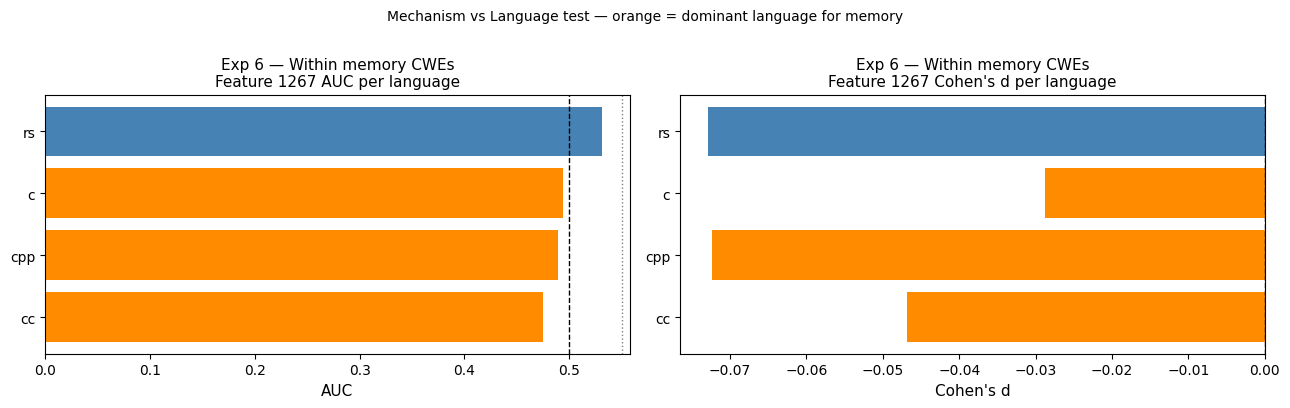

In [51]:
if not exp6_df.empty:
    colors6 = ["darkorange" if r else "steelblue" for r in exp6_df["is_dom"]]

    fig, axes = plt.subplots(1, 2, figsize=(13, max(4, len(exp6_df) * 0.45 + 1)))

    axes[0].barh(exp6_df["lang"], exp6_df["auc"], color=colors6)
    axes[0].axvline(0.5,  color="black", linestyle="--", lw=1)
    axes[0].axvline(0.55, color="gray",  linestyle=":",  lw=1)
    axes[0].set_xlabel("AUC", fontsize=11)
    axes[0].set_title(f"Exp 6 — Within {PRIMARY_CWE_FAMILY} CWEs\nFeature {FEATURE} AUC per language",
                      fontsize=11)
    axes[0].invert_yaxis()

    axes[1].barh(exp6_df["lang"], exp6_df["cohens_d"], color=colors6)
    axes[1].axvline(0, color="black", linestyle="--", lw=1)
    axes[1].set_xlabel("Cohen's d", fontsize=11)
    axes[1].set_title(f"Exp 6 — Within {PRIMARY_CWE_FAMILY} CWEs\nFeature {FEATURE} Cohen's d per language",
                      fontsize=11)
    axes[1].invert_yaxis()

    plt.suptitle(f"Mechanism vs Language test — orange = dominant language for {PRIMARY_CWE_FAMILY}",
                 fontsize=10, y=1.01)
    plt.tight_layout()
    plt.savefig(f"exp6_within_{PRIMARY_CWE_FAMILY}_per_lang_feature{FEATURE}.png", dpi=150)
    plt.show()

---
## Summary

| Exp | Test | Language-detector prediction | Mechanism-detector prediction |
|---|---|---|---|
| 1 | Within-primary-CWE t-test | p > 0.05, d ≈ 0 | p < 0.05, \|d\| > 0.2 |
| 2 | Within-dominant-language t-test | p > 0.05, d ≈ 0 | p < 0.05, \|d\| > 0.2 |
| 3 | Fisher: lang vs vuln | F_lang >> F_vuln | F_vuln ≥ F_lang |
| 4 | Per-language AUC (global) | All ≈ 0.5 | > 0.5 in multiple languages |
| 5 | CWE × Language heatmap | High AUC only where language matches | High AUC across languages within target CWE |
| 6 | Within-primary-CWE per-language AUC | > 0.5 in only one language | > 0.5 in ≥ 2 languages |

In [52]:
print("=" * 65)
print(f"SUMMARY — Feature {FEATURE}  (layer {LAYER}, primary CWE family: {PRIMARY_CWE_FAMILY})")
print("=" * 65)

print(f"\nExp 1 (Within-{PRIMARY_CWE_FAMILY} t-test):")
print(f"  AUC={auc1:.3f}  Cohen's d={d1:.3f}  p={p1:.4f}")

print(f"\nExp 2 (Within-dominant-language t-test):")
print(f"  AUC={auc2:.3f}  Cohen's d={d2:.3f}  p={p2:.4f}  langs={dom_langs_present}")

print(f"\nExp 3 (Fisher scores):")
print(f"  F_lang_c   = {fisher_lang_c[FEATURE]:.4f}  rank {rank_of(fisher_lang_c,   FEATURE)}/{n_feat}")
print(f"  F_lang_dom = {fisher_lang_dom[FEATURE]:.4f}  rank {rank_of(fisher_lang_dom, FEATURE)}/{n_feat}")
print(f"  F_vuln     = {fisher_vuln[FEATURE]:.4f}  rank {rank_of(fisher_vuln,     FEATURE)}/{n_feat}")
print(f"  F_vuln_{PRIMARY_CWE_FAMILY} = {fisher_vuln_prim[FEATURE]:.4f}  rank {rank_of(fisher_vuln_prim, FEATURE)}/{n_feat}")

print(f"\nExp 4 (Per-language AUC):")
print(f"  Mean AUC C-family      = {c_auc:.3f}")
print(f"  Mean AUC dominant lang = {dom_auc:.3f}")
print(f"  Mean AUC non-C         = {non_c_auc:.3f}")

print(f"\nExp 6 (Within-{PRIMARY_CWE_FAMILY} per-language AUC):")
if not exp6_df.empty:
    for _, r in exp6_df.iterrows():
        flag = " ← dominant" if r["is_dom"] else ""
        print(f"  {r['lang']:6s}  AUC={r['auc']:.3f}  d={r['cohens_d']:+.3f}  p={r['p_value']:.3f}  n={int(r['n_pairs'])}{flag}")
else:
    print("  (no data)")

SUMMARY — Feature 1267  (layer 11, primary CWE family: memory)

Exp 1 (Within-memory t-test):
  AUC=0.492  Cohen's d=-0.032  p=0.4583

Exp 2 (Within-dominant-language t-test):
  AUC=0.491  Cohen's d=-0.031  p=0.3800  langs=['c', 'cc', 'cpp']

Exp 3 (Fisher scores):
  F_lang_c   = 0.1701  rank 382/16384
  F_lang_dom = 0.1701  rank 382/16384
  F_vuln     = 0.0003  rank 6184/16384
  F_vuln_memory = 0.0005  rank 6930/16384

Exp 4 (Per-language AUC):
  Mean AUC C-family      = 0.486
  Mean AUC dominant lang = 0.486
  Mean AUC non-C         = 0.503

Exp 6 (Within-memory per-language AUC):
  rs      AUC=0.531  d=-0.073  p=0.893  n=8
  c       AUC=0.494  d=-0.029  p=0.548  n=874 ← dominant
  cpp     AUC=0.489  d=-0.072  p=0.741  n=43 ← dominant
  cc      AUC=0.475  d=-0.047  p=0.724  n=115 ← dominant
